# Chapter 34 — End-to-End Detection Pipeline

## Input

A raw 4D microscopy volume with shape:

```text
(T, Z, Y, X)
```

## Output

A ranked table containing the **top 200 detections per frame**.

## Pipeline

1. Load the raw Zarr image and GEFF ground truth.
2. Generate high-recall multiscale LoG proposals.
3. Consolidate duplicate proposals with 3D non-maximum suppression.
4. Compute handcrafted 2D and 3D image features.
5. Build a spatial candidate graph.
6. Compute graph-neighborhood features.
7. Train a distance-ranking model on labeled timepoints.
8. Rank every candidate in every requested frame.
9. Keep the top 200 detections per frame.
10. Save both the selected detections and the full ranked candidate pool.

The notebook is organized around reusable functions so later chapters can import or copy the pipeline without rebuilding it cell by cell.


## What Makes This Chapter Different

Earlier chapters tested individual components. This chapter turns those components into a single reusable detection system.

The primary reusable entry point is:

```python
results = run_detection_pipeline(...)
```

It accepts a raw volume, a trained ranking model, and a list of timepoints. It returns:

- `selected_detections`: top-k detections per frame
- `full_ranked_candidates`: every ranked candidate
- `frame_summary`: runtime and candidate-count diagnostics


In [1]:

!pip install -q zarr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 33.9 MB/s eta 0:00:00


In [2]:

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from time import perf_counter
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from skimage.feature import blob_log
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from IPython.display import display


In [3]:

@dataclass(frozen=True)
class DetectionConfig:
    sample_id: str = "44b6_12dfb391"

    nms_radius: float = 3.0
    oracle_radius: float = 6.0
    target_distance_clip: float = 20.0

    graph_radius_physical: float = 12.0
    max_graph_neighbors: int = 16

    patch_radius_2d: int = 4
    patch_radius_z: int = 2
    patch_radius_xy: int = 4

    top_k: int = 200

    train_timesteps: tuple[int, ...] = (0, 8, 20, 40)
    validation_timesteps: tuple[int, ...] = (60, 80)

    coordinate_scale_zyx: tuple[float, float, float] = (
        1.625,
        0.40625,
        0.40625,
    )


CONFIG = DetectionConfig()

PROPOSAL_CONFIGS = (
    {
        "name": "small_sensitive",
        "min_sigma": 1.5,
        "max_sigma": 2.5,
        "num_sigma": 3,
        "threshold": 0.08,
    },
    {
        "name": "medium_sensitive",
        "min_sigma": 2.5,
        "max_sigma": 3.5,
        "num_sigma": 3,
        "threshold": 0.10,
    },
    {
        "name": "medium_strict",
        "min_sigma": 2.5,
        "max_sigma": 4.0,
        "num_sigma": 4,
        "threshold": 0.15,
    },
    {
        "name": "large_sensitive",
        "min_sigma": 3.5,
        "max_sigma": 5.0,
        "num_sigma": 4,
        "threshold": 0.08,
    },
)

print(CONFIG)


DetectionConfig(sample_id='44b6_12dfb391', nms_radius=3.0, oracle_radius=6.0, target_distance_clip=20.0, graph_radius_physical=12.0, max_graph_neighbors=16, patch_radius_2d=4, patch_radius_z=2, patch_radius_xy=4, top_k=200, train_timesteps=(0, 8, 20, 40), validation_timesteps=(60, 80), coordinate_scale_zyx=(1.625, 0.40625, 0.40625))


## Load the Competition Sample

The loader verifies the expected Kaggle input paths before opening the arrays.


In [4]:

def load_competition_sample(
    sample_id: str,
    competition_root: Path | str = (
        "/kaggle/input/competitions/"
        "biohub-cell-tracking-during-development"
    ),
):
    competition_root = Path(competition_root)

    if not competition_root.exists():
        raise FileNotFoundError(
            "Competition data is not attached. In Kaggle, select "
            "'Add Input' and attach 'Biohub Cell Tracking During Development'."
        )

    image_path = competition_root / "train" / f"{sample_id}.zarr"
    geff_path = competition_root / "train" / f"{sample_id}.geff"

    if not image_path.exists():
        raise FileNotFoundError(f"Image Zarr was not found: {image_path}")

    if not geff_path.exists():
        raise FileNotFoundError(f"GEFF ground truth was not found: {geff_path}")

    image_group = zarr.open(image_path, mode="r")
    geff_group = zarr.open(geff_path, mode="r")

    if "0" not in image_group:
        raise KeyError(
            f"The image group at {image_path} does not contain array key '0'."
        )

    image = image_group["0"]

    required_geff_paths = [
        "nodes/ids",
        "nodes/props/t/values",
        "nodes/props/z/values",
        "nodes/props/y/values",
        "nodes/props/x/values",
    ]

    missing = [
        path
        for path in required_geff_paths
        if path not in geff_group
    ]

    if missing:
        raise KeyError(
            "The GEFF file is missing required arrays: "
            + ", ".join(missing)
        )

    nodes_df = pd.DataFrame(
        {
            "node_id": geff_group["nodes/ids"][:],
            "t": geff_group["nodes/props/t/values"][:],
            "z": geff_group["nodes/props/z/values"][:],
            "y": geff_group["nodes/props/y/values"][:],
            "x": geff_group["nodes/props/x/values"][:],
        }
    )

    return image, nodes_df, image_path, geff_path


image, nodes_df, image_path, geff_path = load_competition_sample(
    CONFIG.sample_id
)

print("Image path:", image_path)
print("GEFF path:", geff_path)
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("GT nodes:", len(nodes_df))

display(nodes_df.head())


Image path: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_12dfb391.zarr
GEFF path: /kaggle/input/competitions/biohub-cell-tracking-during-development/train/44b6_12dfb391.geff
Image shape: (100, 64, 256, 256)
Image dtype: uint16
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


## Core Distance and Evaluation Utilities


In [5]:

def pairwise_distances_3d(
    points_a: np.ndarray,
    points_b: np.ndarray,
) -> np.ndarray:
    if len(points_a) == 0 or len(points_b) == 0:
        return np.zeros(
            (len(points_a), len(points_b)),
            dtype=np.float32,
        )

    return cdist(
        points_a.astype(np.float32),
        points_b.astype(np.float32),
    )


def evaluate_candidate_coverage(
    candidate_df: pd.DataFrame,
    gt_df: pd.DataFrame,
    radius: float,
) -> dict:
    if len(gt_df) == 0:
        return {
            "num_gt": 0,
            "num_pred": len(candidate_df),
            "gt_detected": 0,
            "gt_missed": 0,
            "gt_recall": np.nan,
            "pred_matched": 0,
            "precision_like": np.nan,
        }

    if len(candidate_df) == 0:
        return {
            "num_gt": len(gt_df),
            "num_pred": 0,
            "gt_detected": 0,
            "gt_missed": len(gt_df),
            "gt_recall": 0.0,
            "pred_matched": 0,
            "precision_like": 0.0,
        }

    gt_points = gt_df[["z", "y", "x"]].to_numpy(dtype=np.float32)
    pred_points = candidate_df[["z", "y", "x"]].to_numpy(
        dtype=np.float32
    )

    distances = pairwise_distances_3d(
        gt_points,
        pred_points,
    )

    gt_min_distance = distances.min(axis=1)
    pred_min_distance = distances.min(axis=0)

    gt_detected = int(
        (gt_min_distance <= radius).sum()
    )

    pred_matched = int(
        (pred_min_distance <= radius).sum()
    )

    return {
        "num_gt": len(gt_df),
        "num_pred": len(candidate_df),
        "gt_detected": gt_detected,
        "gt_missed": len(gt_df) - gt_detected,
        "gt_recall": gt_detected / len(gt_df),
        "pred_matched": pred_matched,
        "precision_like": pred_matched / len(candidate_df),
    }


## Multiscale Proposal Detector

Every LoG configuration sees a different range of cell sizes and contrast levels. Their candidate sets are merged before 3D consolidation.


In [6]:

def detect_log_configuration(
    frame_3d: np.ndarray,
    proposal_config: dict,
) -> pd.DataFrame:
    rows: list[dict] = []

    for z_index in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z_index].astype(np.float32)

        minimum = float(slice_2d.min())
        maximum = float(slice_2d.max())

        if maximum <= minimum:
            continue

        normalized_slice = (
            slice_2d - minimum
        ) / (maximum - minimum)

        blobs = blob_log(
            normalized_slice,
            min_sigma=proposal_config["min_sigma"],
            max_sigma=proposal_config["max_sigma"],
            num_sigma=proposal_config["num_sigma"],
            threshold=proposal_config["threshold"],
        )

        for y_value, x_value, sigma_value in blobs:
            y_index = int(
                np.clip(
                    round(float(y_value)),
                    0,
                    frame_3d.shape[1] - 1,
                )
            )

            x_index = int(
                np.clip(
                    round(float(x_value)),
                    0,
                    frame_3d.shape[2] - 1,
                )
            )

            rows.append(
                {
                    "z": int(z_index),
                    "y": y_index,
                    "x": x_index,
                    "sigma": float(sigma_value),
                    "proposal_source": proposal_config["name"],
                    "proposal_peak_intensity": float(
                        frame_3d[z_index, y_index, x_index]
                    ),
                }
            )

    columns = [
        "z",
        "y",
        "x",
        "sigma",
        "proposal_source",
        "proposal_peak_intensity",
    ]

    return pd.DataFrame(rows, columns=columns)


In [7]:

def generate_multiscale_proposals(
    frame_3d: np.ndarray,
    proposal_configs: Iterable[dict] = PROPOSAL_CONFIGS,
) -> pd.DataFrame:
    proposal_tables = [
        detect_log_configuration(
            frame_3d,
            proposal_config,
        )
        for proposal_config in proposal_configs
    ]

    proposal_tables = [
        table
        for table in proposal_tables
        if not table.empty
    ]

    output_columns = [
        "z",
        "y",
        "x",
        "sigma",
        "proposal_count",
        "proposal_sources",
        "proposal_peak_intensity",
    ]

    if not proposal_tables:
        return pd.DataFrame(columns=output_columns)

    combined = pd.concat(
        proposal_tables,
        ignore_index=True,
    )

    aggregated = (
        combined
        .groupby(["z", "y", "x"], as_index=False)
        .agg(
            sigma=("sigma", "mean"),
            proposal_count=("proposal_source", "nunique"),
            proposal_sources=(
                "proposal_source",
                lambda values: "|".join(
                    sorted(set(values))
                ),
            ),
            proposal_peak_intensity=(
                "proposal_peak_intensity",
                "max",
            ),
        )
    )

    return aggregated[output_columns]


## 3D Non-Maximum Suppression

The proposal union contains duplicates from neighboring slices and detector settings. Greedy 3D NMS keeps the strongest candidate in each local cluster.


In [8]:

def greedy_3d_nms(
    candidate_df: pd.DataFrame,
    radius: float,
) -> pd.DataFrame:
    if candidate_df.empty:
        return candidate_df.copy()

    working_df = (
        candidate_df
        .sort_values(
            [
                "proposal_count",
                "proposal_peak_intensity",
            ],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    kept_rows: list[pd.Series] = []

    while not working_df.empty:
        keep_row = working_df.iloc[0].copy()
        kept_rows.append(keep_row)

        keep_point = np.array(
            [
                keep_row["z"],
                keep_row["y"],
                keep_row["x"],
            ],
            dtype=np.float32,
        )

        points = working_df[
            ["z", "y", "x"]
        ].to_numpy(dtype=np.float32)

        distances = np.linalg.norm(
            points - keep_point,
            axis=1,
        )

        working_df = (
            working_df[
                distances > radius
            ]
            .reset_index(drop=True)
        )

    return pd.DataFrame(kept_rows).reset_index(drop=True)


## Handcrafted 2D Image Features


In [9]:

def compute_2d_features(
    frame_3d: np.ndarray,
    candidate_df: pd.DataFrame,
    patch_radius: int,
) -> pd.DataFrame:
    rows: list[dict] = []

    for row in candidate_df.itertuples(index=False):
        z_index = int(row.z)
        y_index = int(row.y)
        x_index = int(row.x)

        y_start = max(0, y_index - patch_radius)
        y_stop = min(
            frame_3d.shape[1],
            y_index + patch_radius + 1,
        )

        x_start = max(0, x_index - patch_radius)
        x_stop = min(
            frame_3d.shape[2],
            x_index + patch_radius + 1,
        )

        patch = frame_3d[
            z_index,
            y_start:y_stop,
            x_start:x_stop,
        ].astype(np.float32)

        if patch.size == 0:
            continue

        center_intensity = float(
            frame_3d[z_index, y_index, x_index]
        )

        patch_mean = float(patch.mean())
        patch_max = float(patch.max())
        patch_std = float(patch.std())
        local_contrast = patch_max - patch_mean

        peak_y, peak_x = np.unravel_index(
            np.argmax(patch),
            patch.shape,
        )

        patch_center_y = (
            patch.shape[0] - 1
        ) / 2.0

        patch_center_x = (
            patch.shape[1] - 1
        ) / 2.0

        center_to_patch_max_dist = float(
            np.hypot(
                peak_y - patch_center_y,
                peak_x - patch_center_x,
            )
        )

        yy, xx = np.indices(patch.shape)
        mass = patch.astype(np.float64)
        mass_sum = float(mass.sum())

        if mass_sum > 0:
            center_of_mass_y = float(
                (yy * mass).sum() / mass_sum
            )

            center_of_mass_x = float(
                (xx * mass).sum() / mass_sum
            )

            patch_com_offset = float(
                np.hypot(
                    center_of_mass_y - patch_center_y,
                    center_of_mass_x - patch_center_x,
                )
            )
        else:
            patch_com_offset = 0.0

        is_near_border = int(
            z_index <= 1
            or z_index >= frame_3d.shape[0] - 2
            or y_index <= patch_radius
            or y_index >= frame_3d.shape[1] - patch_radius - 1
            or x_index <= patch_radius
            or x_index >= frame_3d.shape[2] - patch_radius - 1
        )

        rows.append(
            {
                "z": z_index,
                "y": y_index,
                "x": x_index,
                "center_intensity": center_intensity,
                "patch_mean": patch_mean,
                "patch_max": patch_max,
                "patch_std": patch_std,
                "local_contrast": local_contrast,
                "center_to_patch_max_dist": (
                    center_to_patch_max_dist
                ),
                "patch_com_offset": patch_com_offset,
                "is_near_border": is_near_border,
            }
        )

    return pd.DataFrame(rows)


## Handcrafted 3D Image Features


In [10]:

def extract_patch_3d(
    frame_3d: np.ndarray,
    z_index: int,
    y_index: int,
    x_index: int,
    radius_z: int,
    radius_xy: int,
):
    z_start = max(0, z_index - radius_z)
    z_stop = min(
        frame_3d.shape[0],
        z_index + radius_z + 1,
    )

    y_start = max(0, y_index - radius_xy)
    y_stop = min(
        frame_3d.shape[1],
        y_index + radius_xy + 1,
    )

    x_start = max(0, x_index - radius_xy)
    x_stop = min(
        frame_3d.shape[2],
        x_index + radius_xy + 1,
    )

    patch = frame_3d[
        z_start:z_stop,
        y_start:y_stop,
        x_start:x_stop,
    ].astype(np.float32)

    bounds = (
        z_start,
        z_stop,
        y_start,
        y_stop,
        x_start,
        x_stop,
    )

    return patch, bounds


In [11]:

def compute_3d_features(
    frame_3d: np.ndarray,
    candidate_df: pd.DataFrame,
    radius_z: int,
    radius_xy: int,
) -> pd.DataFrame:
    rows: list[dict] = []

    for row in candidate_df.itertuples(index=False):
        z_index = int(row.z)
        y_index = int(row.y)
        x_index = int(row.x)

        patch, bounds = extract_patch_3d(
            frame_3d,
            z_index,
            y_index,
            x_index,
            radius_z,
            radius_xy,
        )

        if patch.size == 0:
            continue

        (
            z_start,
            _,
            y_start,
            _,
            x_start,
            _,
        ) = bounds

        local_z = z_index - z_start
        local_y = y_index - y_start
        local_x = x_index - x_start

        center_voxel = float(
            patch[local_z, local_y, local_x]
        )

        volume_mean = float(patch.mean())
        volume_std = float(patch.std())
        volume_max = float(patch.max())

        z_line = patch[
            :,
            local_y,
            local_x,
        ]

        neighboring_slices = []

        if local_z - 1 >= 0:
            neighboring_slices.append(
                patch[local_z - 1]
            )

        if local_z + 1 < patch.shape[0]:
            neighboring_slices.append(
                patch[local_z + 1]
            )

        if neighboring_slices:
            neighboring_slice_mean = float(
                np.mean(
                    [
                        neighbor.mean()
                        for neighbor in neighboring_slices
                    ]
                )
            )
        else:
            neighboring_slice_mean = volume_mean

        peak_z, _, _ = np.unravel_index(
            np.argmax(patch),
            patch.shape,
        )

        zz, yy, xx = np.indices(patch.shape)
        mass = patch.astype(np.float64)
        mass_sum = float(mass.sum())

        if mass_sum > 0:
            center_of_mass_z = float(
                (zz * mass).sum() / mass_sum
            )

            center_of_mass_y = float(
                (yy * mass).sum() / mass_sum
            )

            center_of_mass_x = float(
                (xx * mass).sum() / mass_sum
            )

            mass_center_offset_3d = float(
                np.sqrt(
                    (center_of_mass_z - local_z) ** 2
                    + (center_of_mass_y - local_y) ** 2
                    + (center_of_mass_x - local_x) ** 2
                )
            )
        else:
            mass_center_offset_3d = 0.0

        per_slice_means = np.array(
            [
                float(slice_2d.mean())
                for slice_2d in patch
            ],
            dtype=np.float32,
        )

        rows.append(
            {
                "z": z_index,
                "y": y_index,
                "x": x_index,
                "center_voxel": center_voxel,
                "vol_mean": volume_mean,
                "vol_std": volume_std,
                "vol_max": volume_max,
                "z_line_mean": float(z_line.mean()),
                "z_line_std": float(z_line.std()),
                "z_line_max": float(z_line.max()),
                "center_over_vol_mean": float(
                    center_voxel / (volume_mean + 1e-6)
                ),
                "center_minus_vol_mean": float(
                    center_voxel - volume_mean
                ),
                "center_slice_minus_neighbor_mean": float(
                    patch[local_z].mean()
                    - neighboring_slice_mean
                ),
                "slice_mean_std": float(
                    per_slice_means.std()
                ),
                "z_peak_offset": int(
                    abs(int(peak_z) - local_z)
                ),
                "mass_center_offset_3d": (
                    mass_center_offset_3d
                ),
                "peak_to_mean_ratio": float(
                    volume_max / (volume_mean + 1e-6)
                ),
                "bright_fraction": float(
                    (patch > volume_mean).mean()
                ),
            }
        )

    return pd.DataFrame(rows)


## Candidate Graph and Graph Features

The graph uses physical coordinate scaling so distance in `z` is not treated as equivalent to distance in `x` or `y`.


In [12]:

def build_candidate_graph(
    candidate_df: pd.DataFrame,
    coordinate_scale_zyx: tuple[float, float, float],
    radius_physical: float,
    max_neighbors: int,
) -> dict:
    coordinates_voxel = candidate_df[
        ["z", "y", "x"]
    ].to_numpy(dtype=np.float32)

    if len(coordinates_voxel) == 0:
        return {
            "coordinates_physical": np.empty(
                (0, 3),
                dtype=np.float32,
            ),
            "edge_index": np.empty(
                (2, 0),
                dtype=np.int64,
            ),
            "edge_distance": np.empty(
                (0,),
                dtype=np.float32,
            ),
        }

    coordinate_scale = np.asarray(
        coordinate_scale_zyx,
        dtype=np.float32,
    )

    coordinates_physical = (
        coordinates_voxel
        * coordinate_scale
    )

    tree = cKDTree(coordinates_physical)

    source_nodes: list[int] = []
    target_nodes: list[int] = []
    edge_distances: list[float] = []

    for source_index, point in enumerate(
        coordinates_physical
    ):
        neighbors = tree.query_ball_point(
            point,
            r=radius_physical,
        )

        neighbors = [
            neighbor
            for neighbor in neighbors
            if neighbor != source_index
        ]

        if not neighbors:
            continue

        distances = np.linalg.norm(
            coordinates_physical[neighbors] - point,
            axis=1,
        )

        order = np.argsort(
            distances
        )[:max_neighbors]

        for order_index in order:
            source_nodes.append(source_index)
            target_nodes.append(
                int(neighbors[order_index])
            )
            edge_distances.append(
                float(distances[order_index])
            )

    if source_nodes:
        edge_index = np.asarray(
            [source_nodes, target_nodes],
            dtype=np.int64,
        )

        edge_distance = np.asarray(
            edge_distances,
            dtype=np.float32,
        )
    else:
        edge_index = np.empty(
            (2, 0),
            dtype=np.int64,
        )

        edge_distance = np.empty(
            (0,),
            dtype=np.float32,
        )

    return {
        "coordinates_physical": coordinates_physical,
        "edge_index": edge_index,
        "edge_distance": edge_distance,
    }


In [13]:

GRAPH_FEATURE_COLUMNS = [
    "graph_neighbor_count",
    "graph_mean_neighbor_distance",
    "graph_min_neighbor_distance",
    "graph_mean_neighbor_intensity",
    "graph_mean_neighbor_contrast",
    "graph_mean_neighbor_proposal_count",
]


def compute_graph_features(
    candidate_df: pd.DataFrame,
    graph: dict,
) -> pd.DataFrame:
    result = candidate_df.copy().reset_index(drop=True)

    number_of_nodes = len(result)
    edge_index = graph["edge_index"]
    edge_distance = graph["edge_distance"]

    feature_arrays = {
        column: np.zeros(
            number_of_nodes,
            dtype=np.float32,
        )
        for column in GRAPH_FEATURE_COLUMNS
    }

    if number_of_nodes == 0 or edge_index.shape[1] == 0:
        for column, values in feature_arrays.items():
            result[column] = values
        return result

    source_nodes = edge_index[0]
    target_nodes = edge_index[1]

    intensity = result[
        "center_intensity"
    ].to_numpy(dtype=np.float32)

    contrast = result[
        "local_contrast"
    ].to_numpy(dtype=np.float32)

    proposal_count = result[
        "proposal_count"
    ].to_numpy(dtype=np.float32)

    for node_index in range(number_of_nodes):
        mask = source_nodes == node_index

        if not np.any(mask):
            continue

        neighbors = target_nodes[mask]
        distances = edge_distance[mask]

        feature_arrays[
            "graph_neighbor_count"
        ][node_index] = len(neighbors)

        feature_arrays[
            "graph_mean_neighbor_distance"
        ][node_index] = float(distances.mean())

        feature_arrays[
            "graph_min_neighbor_distance"
        ][node_index] = float(distances.min())

        feature_arrays[
            "graph_mean_neighbor_intensity"
        ][node_index] = float(
            intensity[neighbors].mean()
        )

        feature_arrays[
            "graph_mean_neighbor_contrast"
        ][node_index] = float(
            contrast[neighbors].mean()
        )

        feature_arrays[
            "graph_mean_neighbor_proposal_count"
        ][node_index] = float(
            proposal_count[neighbors].mean()
        )

    for column, values in feature_arrays.items():
        result[column] = values

    return result


## Assemble One Frame into a Feature Table


In [14]:

HANDCRAFTED_FEATURE_COLUMNS = [
    "sigma",
    "proposal_count",
    "proposal_peak_intensity",
    "center_intensity",
    "patch_mean",
    "patch_max",
    "patch_std",
    "local_contrast",
    "center_to_patch_max_dist",
    "patch_com_offset",
    "is_near_border",
    "center_voxel",
    "vol_mean",
    "vol_std",
    "vol_max",
    "z_line_mean",
    "z_line_std",
    "z_line_max",
    "center_over_vol_mean",
    "center_minus_vol_mean",
    "center_slice_minus_neighbor_mean",
    "slice_mean_std",
    "z_peak_offset",
    "mass_center_offset_3d",
    "peak_to_mean_ratio",
    "bright_fraction",
]

MODEL_FEATURE_COLUMNS = (
    HANDCRAFTED_FEATURE_COLUMNS
    + GRAPH_FEATURE_COLUMNS
)


In [15]:

def build_frame_candidate_table(
    raw_volume,
    timepoint: int,
    config: DetectionConfig = CONFIG,
    proposal_configs: Iterable[dict] = PROPOSAL_CONFIGS,
):
    frame_3d = np.asarray(
        raw_volume[timepoint]
    )

    raw_proposals = generate_multiscale_proposals(
        frame_3d,
        proposal_configs=proposal_configs,
    )

    consolidated = greedy_3d_nms(
        raw_proposals,
        radius=config.nms_radius,
    )

    if consolidated.empty:
        empty = consolidated.copy()
        empty["t"] = pd.Series(dtype=np.int32)

        return {
            "timepoint": timepoint,
            "frame_3d": frame_3d,
            "raw_proposals": raw_proposals,
            "consolidated_candidates": consolidated,
            "graph": build_candidate_graph(
                consolidated,
                config.coordinate_scale_zyx,
                config.graph_radius_physical,
                config.max_graph_neighbors,
            ),
            "feature_table": empty,
        }

    coordinate_table = consolidated[
        ["z", "y", "x"]
    ].copy()

    features_2d = compute_2d_features(
        frame_3d,
        coordinate_table,
        patch_radius=config.patch_radius_2d,
    )

    features_3d = compute_3d_features(
        frame_3d,
        coordinate_table,
        radius_z=config.patch_radius_z,
        radius_xy=config.patch_radius_xy,
    )

    feature_table = consolidated.merge(
        features_2d,
        on=["z", "y", "x"],
        how="inner",
        validate="one_to_one",
    )

    feature_table = feature_table.merge(
        features_3d,
        on=["z", "y", "x"],
        how="inner",
        validate="one_to_one",
    )

    graph = build_candidate_graph(
        feature_table,
        coordinate_scale_zyx=(
            config.coordinate_scale_zyx
        ),
        radius_physical=(
            config.graph_radius_physical
        ),
        max_neighbors=config.max_graph_neighbors,
    )

    feature_table = compute_graph_features(
        feature_table,
        graph,
    )

    feature_table["t"] = int(timepoint)

    missing_features = [
        column
        for column in MODEL_FEATURE_COLUMNS
        if column not in feature_table.columns
    ]

    if missing_features:
        raise RuntimeError(
            "Feature construction failed. Missing columns: "
            + ", ".join(missing_features)
        )

    return {
        "timepoint": timepoint,
        "frame_3d": frame_3d,
        "raw_proposals": raw_proposals,
        "consolidated_candidates": consolidated,
        "graph": graph,
        "feature_table": feature_table,
    }


## Add Ground-Truth Training Targets

This function is used only when labels are available. The inference pipeline does not require ground truth.


In [16]:

def add_distance_targets(
    candidate_df: pd.DataFrame,
    gt_df: pd.DataFrame,
    config: DetectionConfig = CONFIG,
) -> pd.DataFrame:
    result = candidate_df.copy()

    if result.empty:
        result["nearest_gt_dist"] = pd.Series(
            dtype=np.float32
        )
        result["target_dist"] = pd.Series(
            dtype=np.float32
        )
        result["oracle_good"] = pd.Series(
            dtype=bool
        )
        return result

    if gt_df.empty:
        nearest_distance = np.full(
            len(result),
            np.inf,
            dtype=np.float32,
        )
    else:
        gt_points = gt_df[
            ["z", "y", "x"]
        ].to_numpy(dtype=np.float32)

        candidate_points = result[
            ["z", "y", "x"]
        ].to_numpy(dtype=np.float32)

        nearest_distance = (
            pairwise_distances_3d(
                gt_points,
                candidate_points,
            ).min(axis=0)
        ).astype(np.float32)

    result["nearest_gt_dist"] = nearest_distance

    result["target_dist"] = np.clip(
        nearest_distance,
        0.0,
        config.target_distance_clip,
    )

    result["oracle_good"] = (
        nearest_distance <= config.oracle_radius
    )

    return result


## Build the Training Dataset


In [17]:

def build_labeled_candidate_dataset(
    raw_volume,
    nodes: pd.DataFrame,
    timepoints: Iterable[int],
    config: DetectionConfig = CONFIG,
):
    labeled_tables: list[pd.DataFrame] = []
    summary_rows: list[dict] = []

    for timepoint in timepoints:
        start_time = perf_counter()

        frame_result = build_frame_candidate_table(
            raw_volume,
            int(timepoint),
            config=config,
        )

        gt_timepoint = nodes[
            nodes["t"] == int(timepoint)
        ].copy()

        labeled_table = add_distance_targets(
            frame_result["feature_table"],
            gt_timepoint,
            config=config,
        )

        labeled_tables.append(
            labeled_table
        )

        elapsed_seconds = (
            perf_counter() - start_time
        )

        coverage = evaluate_candidate_coverage(
            labeled_table,
            gt_timepoint,
            radius=config.oracle_radius,
        )

        summary_rows.append(
            {
                "t": int(timepoint),
                "raw_candidates": len(
                    frame_result["raw_proposals"]
                ),
                "rankable_candidates": len(
                    labeled_table
                ),
                "oracle_good_candidates": int(
                    labeled_table[
                        "oracle_good"
                    ].sum()
                ),
                "proposal_gt_recall": coverage[
                    "gt_recall"
                ],
                "elapsed_seconds": elapsed_seconds,
            }
        )

        print(
            f"t={timepoint}: "
            f"raw={len(frame_result['raw_proposals'])}, "
            f"rankable={len(labeled_table)}, "
            f"oracle_good={int(labeled_table['oracle_good'].sum())}, "
            f"time={elapsed_seconds:.1f}s"
        )

    if not labeled_tables:
        raise RuntimeError(
            "No labeled candidate tables were created."
        )

    labeled_df = pd.concat(
        labeled_tables,
        ignore_index=True,
    )

    summary_df = pd.DataFrame(
        summary_rows
    )

    return labeled_df, summary_df


In [18]:

train_df, train_build_summary_df = (
    build_labeled_candidate_dataset(
        image,
        nodes_df,
        CONFIG.train_timesteps,
        config=CONFIG,
    )
)

print("Training rows:", len(train_df))
display(train_build_summary_df)
display(train_df.head())


t=0: raw=7795, rankable=1768, oracle_good=31, time=6.7s
t=8: raw=7696, rankable=1823, oracle_good=32, time=6.7s
t=20: raw=7968, rankable=1859, oracle_good=31, time=6.7s
t=40: raw=8022, rankable=1941, oracle_good=35, time=7.0s
Training rows: 7391


,t,raw_candidates,rankable_candidates,oracle_good_candidates,proposal_gt_recall,elapsed_seconds
0,0,7795,1768,31,1.0,6.744183
1,8,7696,1823,32,1.0,6.722173
2,20,7968,1859,31,1.0,6.703198
3,40,8022,1941,35,1.0,6.990623


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,...,graph_neighbor_count,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,nearest_gt_dist,target_dist,oracle_good
0,48,86,128,3.250,4,large_sensitive|medium_sensitive|medium_strict...,3140.0,3140.0,2135.111084,3140.0,...,9.0,8.831360,4.958913,1498.444458,319.792847,1.666667,0,41.821049,20.0,False
1,55,81,255,3.625,4,large_sensitive|medium_sensitive|medium_strict...,3013.0,3013.0,2453.733398,3013.0,...,14.0,8.727782,4.942245,1789.857178,334.454498,1.857143,0,71.805290,20.0,False
2,53,183,224,3.750,4,large_sensitive|medium_sensitive|medium_strict...,2721.0,2721.0,2086.185303,2721.0,...,14.0,7.672420,2.333729,1944.428589,445.109406,1.571429,0,110.186203,20.0,False
3,56,10,255,3.250,4,large_sensitive|medium_sensitive|medium_strict...,2346.0,2346.0,1821.955566,2346.0,...,16.0,7.837432,3.275292,1871.812500,298.832336,1.500000,0,86.011627,20.0,False
4,28,170,53,3.250,4,large_sensitive|medium_sensitive|medium_strict...,2288.0,2288.0,1744.012329,2288.0,...,16.0,8.388052,3.447145,1720.812500,309.719910,1.562500,0,27.367865,20.0,False


## Train the Ranking Model

The model predicts clipped nearest-ground-truth distance. Lower predicted distance means a better candidate.


In [19]:

def train_distance_ranker(
    labeled_candidate_df: pd.DataFrame,
    feature_columns: list[str],
    random_state: int = 42,
):
    if labeled_candidate_df.empty:
        raise ValueError(
            "The labeled training table is empty."
        )

    missing_columns = [
        column
        for column in feature_columns + ["target_dist"]
        if column not in labeled_candidate_df.columns
    ]

    if missing_columns:
        raise KeyError(
            "Training data is missing columns: "
            + ", ".join(missing_columns)
        )

    x_train = labeled_candidate_df[
        feature_columns
    ].fillna(0.0)

    y_train = labeled_candidate_df[
        "target_dist"
    ].astype(np.float32)

    model = HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=random_state,
    )

    model.fit(
        x_train,
        y_train,
    )

    train_prediction = model.predict(
        x_train
    )

    training_mae = mean_absolute_error(
        y_train,
        train_prediction,
    )

    return model, training_mae


ranking_model, training_mae = train_distance_ranker(
    train_df,
    MODEL_FEATURE_COLUMNS,
)

print("Training MAE:", training_mae)


Training MAE: 0.7343918386091896


## Rank One Frame

This function converts a feature table into a complete ranked candidate table.


In [20]:

def rank_frame_candidates(
    feature_table: pd.DataFrame,
    ranking_model,
    feature_columns: list[str],
    timepoint: int,
) -> pd.DataFrame:
    if feature_table.empty:
        empty = feature_table.copy()
        empty["pred_dist"] = pd.Series(
            dtype=np.float32
        )
        empty["ranking_score"] = pd.Series(
            dtype=np.float32
        )
        empty["rank_position"] = pd.Series(
            dtype=np.int32
        )
        empty["detection_id"] = pd.Series(
            dtype=str
        )
        return empty

    missing_columns = [
        column
        for column in feature_columns
        if column not in feature_table.columns
    ]

    if missing_columns:
        raise KeyError(
            "Inference feature table is missing columns: "
            + ", ".join(missing_columns)
        )

    ranked = feature_table.copy()

    ranked["pred_dist"] = ranking_model.predict(
        ranked[
            feature_columns
        ].fillna(0.0)
    ).astype(np.float32)

    ranked["ranking_score"] = (
        -ranked["pred_dist"]
    )

    ranked = (
        ranked
        .sort_values(
            [
                "pred_dist",
                "proposal_count",
                "proposal_peak_intensity",
            ],
            ascending=[True, False, False],
        )
        .reset_index(drop=True)
    )

    ranked["rank_position"] = np.arange(
        1,
        len(ranked) + 1,
        dtype=np.int32,
    )

    ranked["detection_id"] = [
        f"chapter34_t{int(timepoint)}_{index}"
        for index in range(len(ranked))
    ]

    return ranked


## Reusable End-to-End Pipeline


In [21]:

def run_detection_pipeline(
    raw_volume,
    ranking_model,
    feature_columns: list[str],
    timepoints: Iterable[int],
    config: DetectionConfig = CONFIG,
    top_k: Optional[int] = None,
    checkpoint_directory: Optional[Path | str] = None,
):
    selected_tables: list[pd.DataFrame] = []
    full_ranked_tables: list[pd.DataFrame] = []
    summary_rows: list[dict] = []

    selected_top_k = (
        config.top_k
        if top_k is None
        else int(top_k)
    )

    checkpoint_path = (
        Path(checkpoint_directory)
        if checkpoint_directory is not None
        else None
    )

    if checkpoint_path is not None:
        checkpoint_path.mkdir(
            parents=True,
            exist_ok=True,
        )

    for timepoint in timepoints:
        timepoint = int(timepoint)
        start_time = perf_counter()

        frame_result = build_frame_candidate_table(
            raw_volume,
            timepoint,
            config=config,
        )

        ranked_table = rank_frame_candidates(
            frame_result["feature_table"],
            ranking_model,
            feature_columns,
            timepoint=timepoint,
        )

        selected_table = (
            ranked_table
            .head(selected_top_k)
            .copy()
        )

        selected_tables.append(
            selected_table
        )

        full_ranked_tables.append(
            ranked_table
        )

        elapsed_seconds = (
            perf_counter() - start_time
        )

        graph_edge_count = int(
            frame_result["graph"][
                "edge_index"
            ].shape[1]
        )

        summary_rows.append(
            {
                "t": timepoint,
                "raw_candidates": len(
                    frame_result["raw_proposals"]
                ),
                "nms_candidates": len(
                    frame_result[
                        "consolidated_candidates"
                    ]
                ),
                "ranked_candidates": len(
                    ranked_table
                ),
                "selected_candidates": len(
                    selected_table
                ),
                "graph_edges": graph_edge_count,
                "elapsed_seconds": elapsed_seconds,
            }
        )

        if checkpoint_path is not None:
            selected_table.to_csv(
                checkpoint_path
                / f"chapter34_selected_t{timepoint:03d}.csv",
                index=False,
            )

            ranked_table.to_csv(
                checkpoint_path
                / f"chapter34_ranked_t{timepoint:03d}.csv",
                index=False,
            )

        print(
            f"t={timepoint}: "
            f"raw={len(frame_result['raw_proposals'])}, "
            f"nms={len(frame_result['consolidated_candidates'])}, "
            f"ranked={len(ranked_table)}, "
            f"selected={len(selected_table)}, "
            f"time={elapsed_seconds:.1f}s"
        )

    if selected_tables:
        selected_detections = pd.concat(
            selected_tables,
            ignore_index=True,
        )
    else:
        selected_detections = pd.DataFrame()

    if full_ranked_tables:
        full_ranked_candidates = pd.concat(
            full_ranked_tables,
            ignore_index=True,
        )
    else:
        full_ranked_candidates = pd.DataFrame()

    frame_summary = pd.DataFrame(
        summary_rows
    )

    return {
        "selected_detections": selected_detections,
        "full_ranked_candidates": full_ranked_candidates,
        "frame_summary": frame_summary,
    }


## Validate the Complete Pipeline

The validation run confirms that the reusable inference functions produce the expected top-k outputs on the held-out labeled frames.


In [22]:

validation_results = run_detection_pipeline(
    raw_volume=image,
    ranking_model=ranking_model,
    feature_columns=MODEL_FEATURE_COLUMNS,
    timepoints=CONFIG.validation_timesteps,
    config=CONFIG,
    top_k=CONFIG.top_k,
)

validation_selected_df = validation_results[
    "selected_detections"
]

validation_full_ranked_df = validation_results[
    "full_ranked_candidates"
]

validation_runtime_df = validation_results[
    "frame_summary"
]

display(validation_runtime_df)
display(validation_selected_df.head())


t=60: raw=9146, nms=2221, ranked=2221, selected=200, time=7.2s
t=80: raw=10040, nms=2460, ranked=2460, selected=200, time=7.8s


,t,raw_candidates,nms_candidates,ranked_candidates,selected_candidates,graph_edges,elapsed_seconds
0,60,9146,2221,2221,200,31517,7.226255
1,80,10040,2460,2460,200,35404,7.756096


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,...,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,pred_dist,ranking_score,rank_position,detection_id
0,12,236,36,3.75,2,medium_sensitive|medium_strict,1467.0,1467.0,1282.086426,1481.0,...,5.879992,2.187723,1381.3750,209.472061,1.3125,60,10.388321,-10.388321,1,chapter34_t60_0
1,12,243,37,2.50,1,small_sensitive,1264.0,1264.0,1201.802490,1385.0,...,5.297501,2.071477,1394.5000,205.917587,1.3750,60,10.841901,-10.841901,2,chapter34_t60_1
2,11,244,40,2.50,1,small_sensitive,1417.0,1417.0,1296.172852,1495.0,...,5.298572,2.071477,1358.1875,197.972061,1.3750,60,11.274562,-11.274562,3,chapter34_t60_2
3,15,241,34,5.00,1,large_sensitive,1435.0,1435.0,1361.283936,1542.0,...,6.099411,2.368824,1361.3750,202.557251,1.4375,60,12.356889,-12.356889,4,chapter34_t60_3
4,11,239,38,5.00,1,large_sensitive,1376.0,1376.0,1355.382690,1495.0,...,5.330277,2.187723,1370.5625,207.445053,1.3750,60,12.429659,-12.429659,5,chapter34_t60_4


In [23]:

validation_metric_rows = []

for timepoint in CONFIG.validation_timesteps:
    gt_timepoint = nodes_df[
        nodes_df["t"] == timepoint
    ].copy()

    full_timepoint = validation_full_ranked_df[
        validation_full_ranked_df["t"] == timepoint
    ].copy()

    for top_k in [25, 50, 100, 200, 400]:
        selected_timepoint = full_timepoint.head(
            top_k
        )

        metrics = evaluate_candidate_coverage(
            selected_timepoint,
            gt_timepoint,
            radius=CONFIG.oracle_radius,
        )

        validation_metric_rows.append(
            {
                "t": timepoint,
                "top_k": top_k,
                **metrics,
            }
        )

validation_metrics_df = pd.DataFrame(
    validation_metric_rows
)

validation_summary_df = (
    validation_metrics_df
    .groupby("top_k", as_index=False)
    .agg(
        mean_gt_recall=("gt_recall", "mean"),
        mean_precision_like=(
            "precision_like",
            "mean",
        ),
        mean_num_pred=("num_pred", "mean"),
    )
)

display(validation_metrics_df)
display(validation_summary_df)


,t,top_k,num_gt,num_pred,gt_detected,gt_missed,gt_recall,pred_matched,precision_like
0,60,25,9,25,1,8,0.111111,3,0.1200
1,60,50,9,50,3,6,0.333333,5,0.1000
2,60,100,9,100,4,5,0.444444,10,0.1000
3,60,200,9,200,6,3,0.666667,14,0.0700
4,60,400,9,400,7,2,0.777778,17,0.0425
5,80,25,6,25,2,4,0.333333,3,0.1200
6,80,50,6,50,2,4,0.333333,4,0.0800
7,80,100,6,100,3,3,0.500000,6,0.0600
8,80,200,6,200,3,3,0.500000,8,0.0400
9,80,400,6,400,4,2,0.666667,9,0.0225


,top_k,mean_gt_recall,mean_precision_like,mean_num_pred
0,25,0.222222,0.1200,25.0
1,50,0.333333,0.0900,50.0
2,100,0.472222,0.0800,100.0
3,200,0.583333,0.0550,200.0
4,400,0.722222,0.0325,400.0


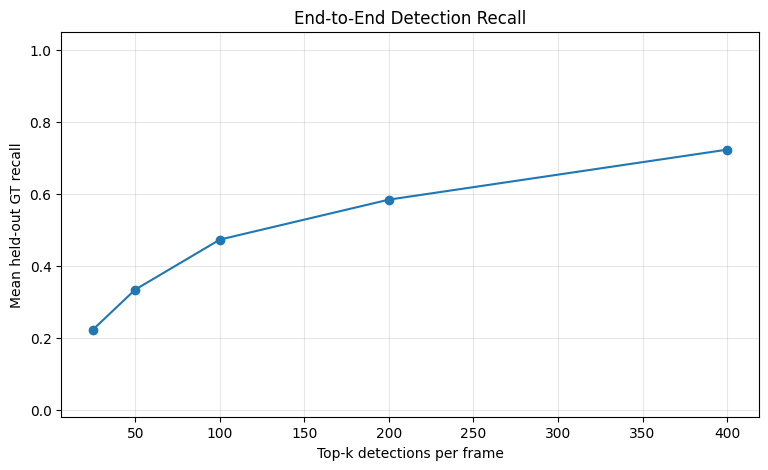

In [24]:

plt.figure(figsize=(9, 5))

plt.plot(
    validation_summary_df["top_k"],
    validation_summary_df["mean_gt_recall"],
    marker="o",
)

plt.title("End-to-End Detection Recall")
plt.xlabel("Top-k detections per frame")
plt.ylabel("Mean held-out GT recall")
plt.ylim(-0.02, 1.05)
plt.grid(True, alpha=0.3)
plt.show()


## Visualize Top-200 Detections


In [25]:

def plot_ranked_detection_overlay(
    frame_3d: np.ndarray,
    gt_df: pd.DataFrame,
    ranked_df: pd.DataFrame,
    top_k: int,
    title: str,
    max_slices: int = 8,
):
    selected_df = ranked_df.head(
        top_k
    ).copy()

    z_values = sorted(
        gt_df["z"].astype(int).unique()
    )[:max_slices]

    if not z_values:
        print("No GT slices are available for this frame.")
        return

    number_of_columns = 4
    number_of_rows = int(
        np.ceil(
            len(z_values)
            / number_of_columns
        )
    )

    figure, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(
            16,
            4 * number_of_rows,
        ),
    )

    axes = np.atleast_1d(
        axes
    ).ravel()

    for axis, z_index in zip(
        axes,
        z_values,
    ):
        axis.imshow(
            frame_3d[z_index],
            cmap="gray",
        )

        gt_slice = gt_df[
            gt_df["z"].astype(int) == z_index
        ]

        selected_slice = selected_df[
            selected_df["z"].astype(int) == z_index
        ]

        axis.scatter(
            gt_slice["x"],
            gt_slice["y"],
            facecolors="none",
            edgecolors="red",
            s=55,
            linewidths=1.5,
            label="GT",
        )

        axis.scatter(
            selected_slice["x"],
            selected_slice["y"],
            marker="x",
            s=35,
            label="selected",
        )

        axis.set_title(f"z={z_index}")
        axis.axis("off")

    for axis in axes[len(z_values):]:
        axis.axis("off")

    figure.suptitle(title)
    plt.tight_layout()
    plt.show()


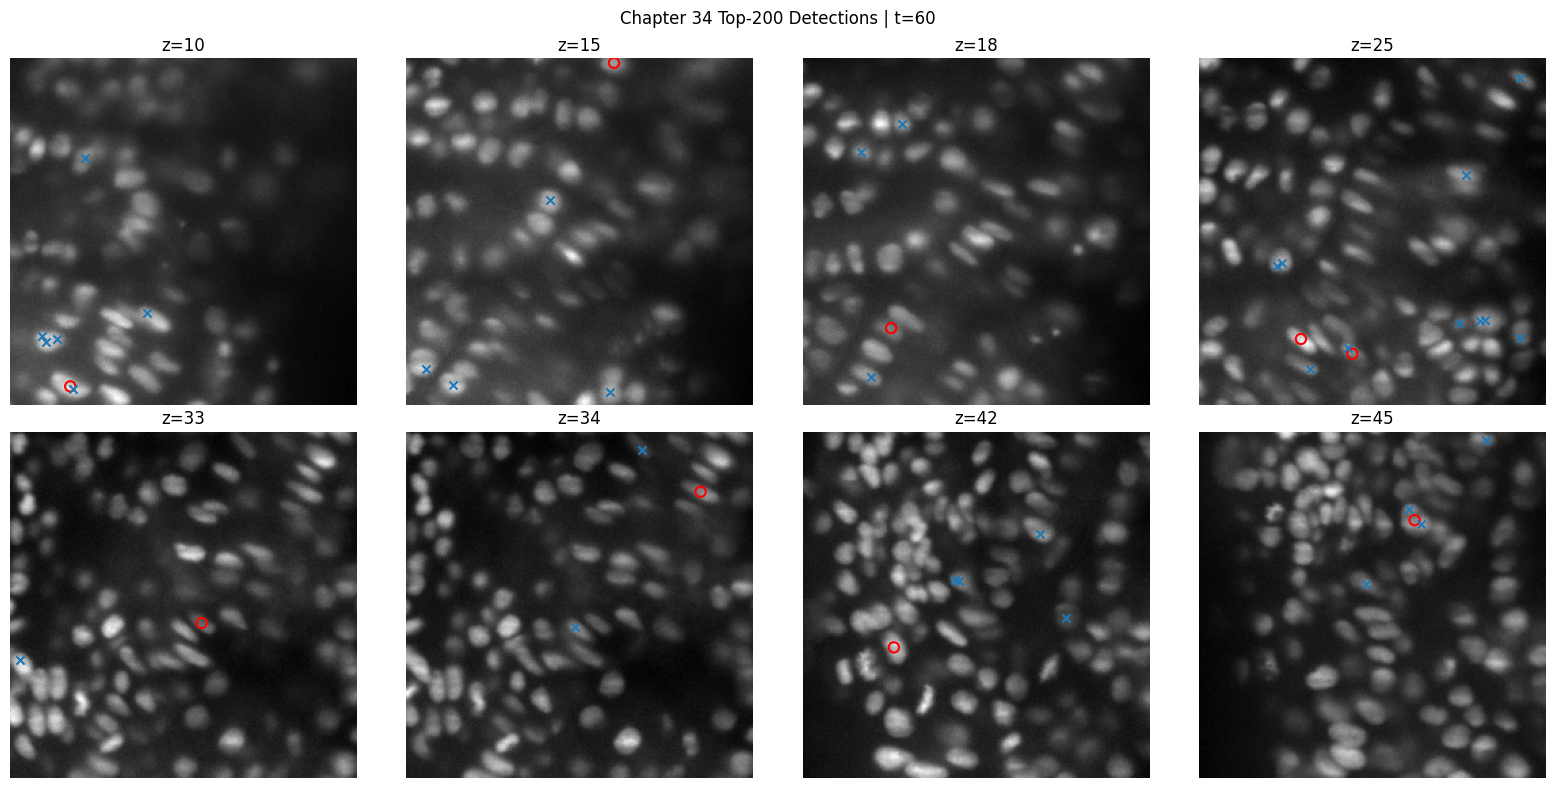

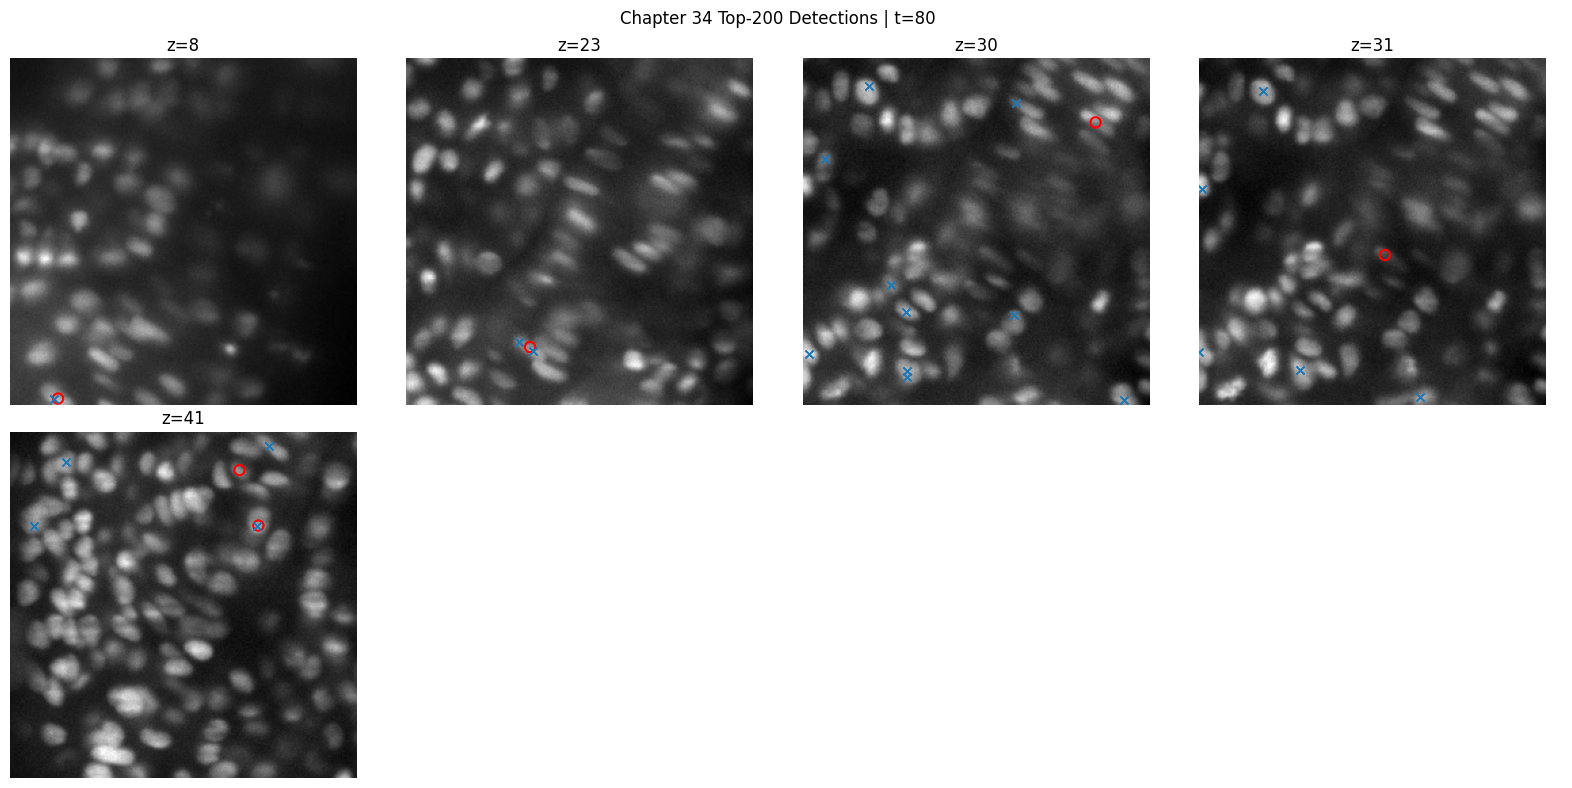

In [26]:

for timepoint in CONFIG.validation_timesteps:
    gt_timepoint = nodes_df[
        nodes_df["t"] == timepoint
    ].copy()

    ranked_timepoint = validation_full_ranked_df[
        validation_full_ranked_df["t"] == timepoint
    ].copy()

    plot_ranked_detection_overlay(
        frame_3d=np.asarray(
            image[timepoint]
        ),
        gt_df=gt_timepoint,
        ranked_df=ranked_timepoint,
        top_k=CONFIG.top_k,
        title=(
            f"Chapter 34 Top-{CONFIG.top_k} "
            f"Detections | t={timepoint}"
        ),
    )


## Run the Pipeline on the Raw Volume

By default, this cell processes all frames in the selected sample.

For a quick test, replace:

```python
inference_timepoints = list(range(image.shape[0]))
```

with:

```python
inference_timepoints = list(range(5))
```

The pipeline writes per-frame checkpoint CSV files so a long run does not depend on a single final save operation.


In [27]:

inference_timepoints = list(
    range(image.shape[0])
)

checkpoint_directory = Path(
    "/kaggle/working/chapter34_checkpoints"
)

pipeline_results = run_detection_pipeline(
    raw_volume=image,
    ranking_model=ranking_model,
    feature_columns=MODEL_FEATURE_COLUMNS,
    timepoints=inference_timepoints,
    config=CONFIG,
    top_k=CONFIG.top_k,
    checkpoint_directory=checkpoint_directory,
)

chapter34_selected_detections_df = pipeline_results[
    "selected_detections"
]

chapter34_full_ranked_candidates_df = pipeline_results[
    "full_ranked_candidates"
]

chapter34_frame_summary_df = pipeline_results[
    "frame_summary"
]

print(
    "Selected detections:",
    len(chapter34_selected_detections_df),
)

print(
    "Full ranked candidates:",
    len(chapter34_full_ranked_candidates_df),
)

display(chapter34_frame_summary_df.head())
display(chapter34_selected_detections_df.head())


t=0: raw=7795, nms=1768, ranked=1768, selected=200, time=6.6s
t=1: raw=7532, nms=1773, ranked=1773, selected=200, time=6.7s
t=2: raw=7886, nms=1799, ranked=1799, selected=200, time=6.9s
t=3: raw=7641, nms=1798, ranked=1798, selected=200, time=6.7s
t=4: raw=7838, nms=1851, ranked=1851, selected=200, time=6.9s
t=5: raw=7421, nms=1754, ranked=1754, selected=200, time=6.7s
t=6: raw=7261, nms=1735, ranked=1735, selected=200, time=6.5s
t=7: raw=7317, nms=1729, ranked=1729, selected=200, time=6.7s
t=8: raw=7696, nms=1823, ranked=1823, selected=200, time=6.5s
t=9: raw=7892, nms=1854, ranked=1854, selected=200, time=6.9s
t=10: raw=8014, nms=1862, ranked=1862, selected=200, time=6.7s
t=11: raw=8196, nms=1941, ranked=1941, selected=200, time=7.0s
t=12: raw=7927, nms=1881, ranked=1881, selected=200, time=6.8s
t=13: raw=7853, nms=1879, ranked=1879, selected=200, time=6.8s
t=14: raw=8018, nms=1859, ranked=1859, selected=200, time=6.9s
t=15: raw=8052, nms=1890, ranked=1890, selected=200, time=6.8s
t=

,t,raw_candidates,nms_candidates,ranked_candidates,selected_candidates,graph_edges,elapsed_seconds
0,0,7795,1768,1768,200,24331,6.639635
1,1,7532,1773,1773,200,24399,6.718771
2,2,7886,1799,1799,200,24695,6.851545
3,3,7641,1798,1798,200,24756,6.742202
4,4,7838,1851,1851,200,25682,6.855745


,z,y,x,sigma,proposal_count,proposal_sources,proposal_peak_intensity,center_intensity,patch_mean,patch_max,...,graph_mean_neighbor_distance,graph_min_neighbor_distance,graph_mean_neighbor_intensity,graph_mean_neighbor_contrast,graph_mean_neighbor_proposal_count,t,pred_dist,ranking_score,rank_position,detection_id
0,41,130,131,4.0,1,medium_strict,1754.0,1754.0,1583.678955,1790.0,...,6.222860,1.625000,1660.5625,294.091064,1.7500,0,7.354238,-7.354238,1,chapter34_t0_0
1,24,123,85,4.0,3,large_sensitive|medium_sensitive|medium_strict,1279.0,1279.0,1216.271606,1353.0,...,7.320772,2.071477,1383.4375,293.540131,1.4375,0,7.437489,-7.437489,2,chapter34_t0_1
2,37,193,95,5.0,1,large_sensitive,1507.0,1507.0,1466.740723,1611.0,...,5.935493,1.723573,1556.0625,249.272369,1.4375,0,7.584010,-7.584010,3,chapter34_t0_2
3,17,255,95,5.0,1,large_sensitive,1195.0,1195.0,1210.688843,1365.0,...,9.283495,2.071477,1226.3125,199.058167,1.5000,0,7.949785,-7.949785,4,chapter34_t0_3
4,25,125,88,3.5,1,medium_sensitive,1192.0,1192.0,1120.629639,1292.0,...,7.531094,1.625000,1371.1875,286.811737,1.5625,0,8.260656,-8.260656,5,chapter34_t0_4


## Validate the Final Output Contract

A valid final detection table must have:

- exactly one timepoint value per row
- rank positions beginning at 1 within each frame
- no more than 200 selected detections per frame
- finite `z`, `y`, `x`, and predicted-distance values
- unique detection IDs


In [28]:

def validate_detection_output(
    selected_df: pd.DataFrame,
    top_k: int,
) -> pd.DataFrame:
    required_columns = [
        "t",
        "detection_id",
        "rank_position",
        "z",
        "y",
        "x",
        "pred_dist",
        "ranking_score",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in selected_df.columns
    ]

    if missing_columns:
        raise KeyError(
            "Detection output is missing columns: "
            + ", ".join(missing_columns)
        )

    if selected_df["detection_id"].duplicated().any():
        raise ValueError(
            "Detection IDs are not unique."
        )

    finite_columns = [
        "z",
        "y",
        "x",
        "pred_dist",
        "ranking_score",
    ]

    if not np.isfinite(
        selected_df[finite_columns]
        .to_numpy(dtype=np.float64)
    ).all():
        raise ValueError(
            "The output contains non-finite coordinates or scores."
        )

    validation_rows = []

    for timepoint, group in selected_df.groupby(
        "t",
        sort=True,
    ):
        expected_ranks = np.arange(
            1,
            len(group) + 1,
        )

        actual_ranks = (
            group
            .sort_values("rank_position")[
                "rank_position"
            ]
            .to_numpy()
        )

        ranks_are_valid = np.array_equal(
            expected_ranks,
            actual_ranks,
        )

        validation_rows.append(
            {
                "t": int(timepoint),
                "num_selected": len(group),
                "within_top_k_limit": (
                    len(group) <= top_k
                ),
                "rank_positions_valid": (
                    ranks_are_valid
                ),
                "unique_coordinates": int(
                    group[
                        ["z", "y", "x"]
                    ]
                    .drop_duplicates()
                    .shape[0]
                ),
            }
        )

    validation_df = pd.DataFrame(
        validation_rows
    )

    if not validation_df[
        "within_top_k_limit"
    ].all():
        raise ValueError(
            "At least one frame contains more than top_k detections."
        )

    if not validation_df[
        "rank_positions_valid"
    ].all():
        raise ValueError(
            "At least one frame has invalid rank positions."
        )

    return validation_df


output_validation_df = validate_detection_output(
    chapter34_selected_detections_df,
    top_k=CONFIG.top_k,
)

display(output_validation_df.head())
print("Output validation passed.")


,t,num_selected,within_top_k_limit,rank_positions_valid,unique_coordinates
0,0,200,True,True,200
1,1,200,True,True,200
2,2,200,True,True,200
3,3,200,True,True,200
4,4,200,True,True,200


Output validation passed.


## Save Final Pipeline Outputs


In [29]:

output_directory = Path(
    "/kaggle/working"
)

selected_output_path = (
    output_directory
    / "chapter34_top200_detections.csv"
)

full_ranked_output_path = (
    output_directory
    / "chapter34_full_ranked_candidates.csv"
)

frame_summary_output_path = (
    output_directory
    / "chapter34_frame_summary.csv"
)

validation_metrics_output_path = (
    output_directory
    / "chapter34_validation_metrics.csv"
)

training_table_output_path = (
    output_directory
    / "chapter34_training_candidates.csv"
)

feature_list_output_path = (
    output_directory
    / "chapter34_model_features.txt"
)

chapter34_selected_detections_df.to_csv(
    selected_output_path,
    index=False,
)

chapter34_full_ranked_candidates_df.to_csv(
    full_ranked_output_path,
    index=False,
)

chapter34_frame_summary_df.to_csv(
    frame_summary_output_path,
    index=False,
)

validation_metrics_df.to_csv(
    validation_metrics_output_path,
    index=False,
)

train_df.to_csv(
    training_table_output_path,
    index=False,
)

feature_list_output_path.write_text(
    "\n".join(MODEL_FEATURE_COLUMNS),
    encoding="utf-8",
)

print("Saved:", selected_output_path)
print("Saved:", full_ranked_output_path)
print("Saved:", frame_summary_output_path)
print("Saved:", validation_metrics_output_path)
print("Saved:", training_table_output_path)
print("Saved:", feature_list_output_path)
print("Checkpoints:", checkpoint_directory)


Saved: /kaggle/working/chapter34_top200_detections.csv
Saved: /kaggle/working/chapter34_full_ranked_candidates.csv
Saved: /kaggle/working/chapter34_frame_summary.csv
Saved: /kaggle/working/chapter34_validation_metrics.csv
Saved: /kaggle/working/chapter34_training_candidates.csv
Saved: /kaggle/working/chapter34_model_features.txt
Checkpoints: /kaggle/working/chapter34_checkpoints


## Reusable API Summary

The complete workflow is now available through these functions:

```python
image, nodes_df, image_path, geff_path = load_competition_sample(
    sample_id
)

train_df, build_summary = build_labeled_candidate_dataset(
    image,
    nodes_df,
    train_timesteps
)

ranking_model, training_mae = train_distance_ranker(
    train_df,
    MODEL_FEATURE_COLUMNS
)

results = run_detection_pipeline(
    raw_volume=image,
    ranking_model=ranking_model,
    feature_columns=MODEL_FEATURE_COLUMNS,
    timepoints=range(image.shape[0]),
    top_k=200
)
```

The main output for Chapter 35 is:

```text
/kaggle/working/chapter34_top200_detections.csv
```

That file contains the ranked detections the tracking pipeline will connect across frames.
